## Linear Regression Evaluation

### Load Dependencies

In [11]:
# Import frameworks
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import pickle

### Load Regression Model

In [12]:
filename = "linear_model1.sav"
model_A = pickle.load(open(filename, 'rb'))

### Load another Model for comparative study

In [13]:
filename = "linear_model2.sav"
model_B = pickle.load(open(filename, 'rb'))

### Store Model as Variable

In [14]:
y_col = "win%"
testing_data = pd.read_csv("2.4.1.testing_data.csv")

# Define different x columns for each model
x_cols = {"Model A": "avg_kill_per_rnd", "Model B": "dmg_indicator"}

# Prepare test data for each model
test_data = {}
for model_name, x_col in x_cols.items():
    try:
        if x_col not in testing_data.columns:
            print(f"Error: '{x_col}' column not found")
        elif y_col not in testing_data.columns:
            print(f"Error: '{y_col}' column not found")
        else:
            temp_data = testing_data.dropna(subset=[x_col, y_col])
            test_data[model_name] = {
                "x_test": np.array(temp_data[x_col]).reshape(-1, 1),
                "y_test": np.array(temp_data[y_col]),
                "x_col": x_col,
            }
            print(
                f"{model_name}: Loaded {len(test_data[model_name]['x_test'])} samples"
            )
    except Exception as e:
        print(f"Error processing {model_name}: {e}")

Model A: Loaded 96 samples
Model B: Loaded 96 samples


### Visually represent Linear Regression through Matplotlib

Model A (avg_kill_per_rnd -> win%) | MSE: 78.193601 | Cost J(theta): 39.096800
Model B (dmg_indicator -> win%) | MSE: 82.531653 | Cost J(theta): 41.265826


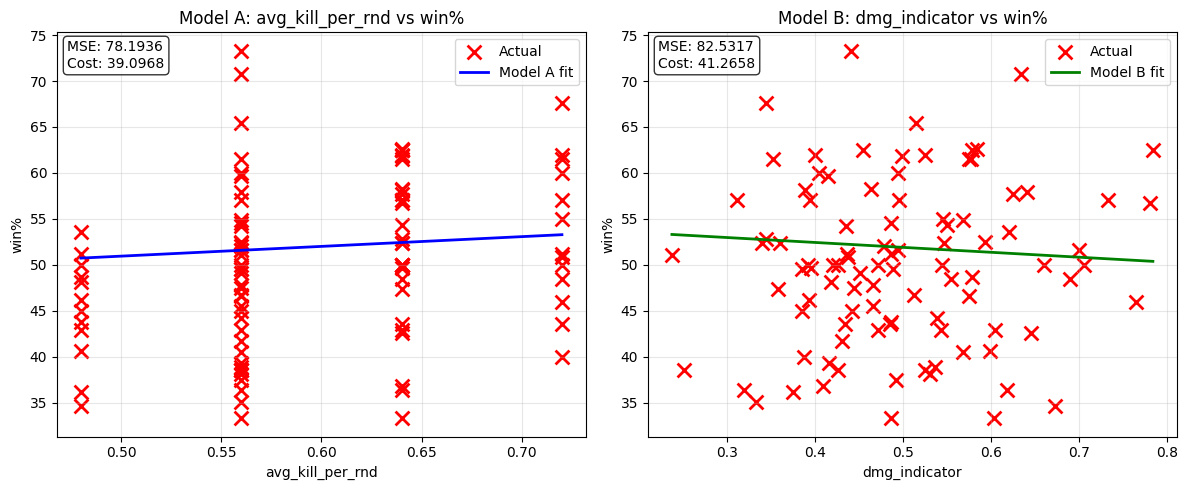

In [15]:
# ...existing code...

# Determine which models are available
models = {}
try:
    models["Model A"] = model_A
except NameError:
    pass

try:
    models["Model B"] = model_B
except NameError:
    pass

if not models or not test_data:
    print("No models or test data available.")
else:
    valid_models = [(name, mdl) for name, mdl in models.items() if name in test_data]
    if not valid_models:
        print("No model has matching test data.")
    else:
        fig, axes = plt.subplots(
            1, len(valid_models), figsize=(6 * len(valid_models), 5)
        )

        if len(valid_models) == 1:
            axes = [axes]

        colors = {"Model A": "blue", "Model B": "green"}

        for idx, (model_name, model) in enumerate(valid_models):
            ax = axes[idx]
            x_test = test_data[model_name]["x_test"]
            y_test = np.ravel(test_data[model_name]["y_test"])
            x_col = test_data[model_name]["x_col"]

            # Predictions
            y_pred = np.ravel(model.predict(x_test))

            # Metrics
            mse = np.mean((y_test - y_pred) ** 2)
            cost = mse / 2.0  # J(theta) = (1/2m) * sum((y_pred - y_true)^2)

            print(
                f"{model_name} ({x_col} -> {y_col}) | MSE: {mse:.6f} | Cost J(theta): {cost:.6f}"
            )

            # Sort for clean line
            order = np.argsort(x_test.flatten())
            x_sorted = x_test.flatten()[order]
            y_pred_sorted = y_pred[order]

            # Scatter plot
            ax.scatter(
                x_test,
                y_test,
                color="red",
                marker="x",
                label="Actual",
                s=100,
                linewidth=2,
            )

            # Regression line
            ax.plot(
                x_sorted,
                y_pred_sorted,
                color=colors.get(model_name, "black"),
                linewidth=2,
                label=f"{model_name} fit",
            )

            # Labels + metric box
            ax.set_title(f"{model_name}: {x_col} vs {y_col}")
            ax.set_xlabel(x_col)
            ax.set_ylabel(y_col)
            ax.legend()
            ax.grid(True, alpha=0.3)
            ax.text(
                0.02,
                0.98,
                f"MSE: {mse:.4f}\nCost: {cost:.4f}",
                transform=ax.transAxes,
                va="top",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
            )

        plt.tight_layout()
        plt.show()

# ...existing code...

### Evaluation Model score

In [24]:
# ...existing code...

# Evaluation Model score (per-model test data + error metrics)
for model_name, model in models.items():
    if model_name not in test_data:
        print(f"{model_name}: no prepared test data")
        continue

    x_t = test_data[model_name]["x_test"]
    y_t = np.ravel(test_data[model_name]["y_test"])
    y_pred = np.ravel(model.predict(x_t))

    test_score = model.score(x_t, y_t)  # R^2
    mse = np.mean((y_t - y_pred) ** 2)
    avg_cost = mse / 2.0  # J(theta)
    abs_error = np.abs(y_t - y_pred)  # per-sample absolute error
    mae = np.mean(abs_error)

    print(f"{model_name} ({test_data[model_name]['x_col']} -> {y_col})")
    print(f"  Test score (R^2): {test_score:.6f}")
    print(f"  MSE: {mse:.6f}")
    print(f"  Average Cost J(theta): {avg_cost:.6f}")
    print(f"  MAE: {mae:.6f}")
    print(f"  Absolute error (first 10): {abs_error[:10]}")

# ...existing code...

Model A (avg_kill_per_rnd -> win%)
  Test score (R^2): -0.003695
  MSE: 78.193601
  Average Cost J(theta): 39.096800
  MAE: 7.131060
  Absolute error (first 10): [16.02603375  8.42341993  0.47658007  4.67396625  1.72451256  8.22451256
  2.42603375  2.07658007  2.42603375 10.17396625]
Model B (dmg_indicator -> win%)
  Test score (R^2): -0.059378
  MSE: 82.531653
  Average Cost J(theta): 41.265826
  MAE: 7.370912
  Absolute error (first 10): [14.8592902   7.59496905  2.20036975  4.63817317  3.3508186  10.00798958
  1.03442853  3.00629908  0.7900991  11.15710551]


## Multiple Feature Linear Regression

In [17]:
filename = "multi_linear_model.sav"
model_C = pickle.load(open(filename, "rb"))

In [18]:
mx_col = ["avg_kill_per_rnd", "k/d", 'kills_total']
testing_data = pd.read_csv("2.4.1.testing_data.csv")
mx_test = np.array(testing_data[mx_col])
my_test = np.array(testing_data["win%"])

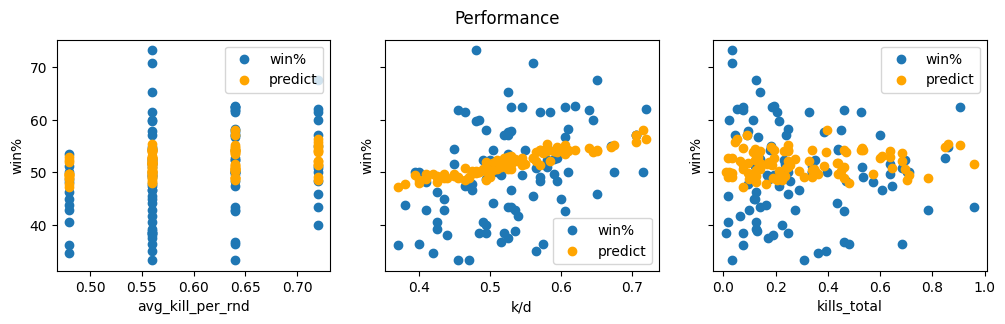

In [19]:
my_pred = model_C.predict(mx_test)

# plot predictions and targets vs original features
fig, ax = plt.subplots(1, len(mx_col), figsize=(12, 3), sharey=True)
for i in range(len(ax)):
    ax[i].scatter(mx_test[:, i], my_test, label="win%")
    ax[i].set_xlabel(mx_col[i])
    ax[i].scatter(mx_test[:, i], my_pred, color="orange", label="predict")
    ax[i].set_ylabel("win%")
    ax[i].legend()
fig.suptitle("Performance")
plt.show()

In [23]:
# ...existing code...

my_pred = model_C.predict(mx_test)

test_score = model_C.score(mx_test, my_test)
mse = np.mean((my_test - my_pred) ** 2)
avg_cost = mse / 2.0  # J(theta)
abs_error = np.abs(my_test - my_pred)  # per-sample absolute error
mae = np.mean(abs_error)

print(f"Test score (R^2): {test_score:.6f}")
print(f"MSE: {mse:.6f}")
print(f"Average Cost J(theta): {avg_cost:.6f}")
print(f"MAE (mean absolute error): {mae:.6f}")
print("Absolute error (first 10):", abs_error[:10])

# ...existing code...

Test score (R^2): 0.068882
MSE: 72.539465
Average Cost J(theta): 36.269732
MAE (mean absolute error): 6.868093
Absolute error (first 10): [17.30109444  9.90358618  3.58414147  6.20441454  0.14895922  9.38781583
  0.39684312  3.15616903  8.11323363  8.38236864]
